# Appendice 1: velocità del vento

Nei dati raccolti da Meteotrentino la maggior parte delle voci relative alle velocità dei venti sono vuote. Tuttavia, per addestrare il modello, non possiamo fornirgli NaN ma solo valori numerici. Pertanto, le opzioni che individuiamo per procedere sono 3:
- 1. rinunciare ai dati dei venti
- 2. porre tutti i NaN a 0
- 3. sostituire i NaN con il valor medio dei dati effettivamente registrati

Tutte e tre le opzioni non ci soddisfano appieno: la prima ci fa rinunciare a dati potenzialmente importanti, mentre la seconda e la terza inseriscono nel modello dati che non sono reali e quindi lo rendono meno veritiero. Una quarta opzione poteva essere campionare dati con la stessa media e varianza dei dati raccolti e sostituirli ai NaN. Scegliamo di non percorrere questa strada poiché trasformerebbe la feature in dati randomici, puro rumore. Questo sarebbe anche peggio di rinunciare ai dati poiché non solo perderemmo le relative informazioni ma rischieremmo di imparare il rumore dei nostri dati.

Per scegliere tra i 3 approcci scegliamo di addestrare un modello con ciascuna delle opzioni e poi adottare nel resto dello studio l'approccio che conduce al modello migliore.

In [1]:
# preliminare
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from  sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import metrics

import sys
sys.path.append('../..')

import src.class_funcs as fs

In [6]:
#scelta seed rng
seed = 58327419

In [7]:
# cominciamo importando il dataframe precedentemente preparato
binary_class_df = pd.read_csv('../../data/processed/dataset_binary_class_processed.csv')

binary_class_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,NO2_3,AQI_3,power_area_50_3,temperature,winds_spd,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,24.0,17.861264,10.950,NaN,0.0,1.0,1.0,4.0,1
1,1,0,0,0,0,0,0,410,1,-0.900969,...,17.0,22.0,14.669913,11.000,NaN,0.0,-2.0,-2.0,0.0,1
2,1,0,0,0,0,0,0,410,1,-0.900969,...,18.0,26.0,16.969367,10.925,NaN,0.0,5.0,0.0,6.0,1
3,1,0,0,0,0,0,0,410,1,-0.900969,...,16.0,26.0,15.329278,10.950,NaN,0.0,-5.0,-1.0,-10.0,1
4,1,0,0,0,0,0,0,410,1,-0.900969,...,16.0,32.0,17.519438,11.550,NaN,0.0,3.0,0.0,2.0,1


## Approccio 1: rinunciare ai dati

In [ ]:
df_1 = binary_class_df.copy()

df_1 = df_1.drop(columns='winds_spd')

df_1.head()

,day,hour,elevation,PM10_1,NO2_1,AQI_1,power_area_50_1,temperature_1,precipitation_5,PM10_2,...,tuesday,wednesday,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Piana Rotaliana,Riva del Garda,Rovereto,Via Bolzano,target
8,1,9,410,19.0,15.0,23.750000,17.446178,10.95,0.0,24.0,...,False,False,True,False,False,False,False,False,False,1
9,1,10,410,22.0,15.0,25.000000,17.484408,11.55,0.0,19.0,...,False,False,True,False,False,False,False,False,False,1
10,1,11,410,26.0,18.0,30.000000,17.774180,12.15,0.0,22.0,...,False,False,True,False,False,False,False,False,False,1
11,1,12,410,23.0,17.0,27.500000,17.936620,12.85,0.0,26.0,...,False,False,True,False,False,False,False,False,False,1
12,1,13,410,30.0,18.0,36.666667,18.968706,13.80,0.0,23.0,...,False,False,True,False,False,False,False,False,False,1


In [ ]:
feature_cols = df_1.columns.difference(['target'])

# creiamo train, valid e test
X_train, X_test, y_train, y_test= train_test_split(df_1[feature_cols], df_1['target'], test_size=0.2, random_state=seed)

# riscalo mettendo la media a 0 e la deviazione std a 1
non_num_features = ['day', 'hour', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday', 'Borgo Valsugana', 'Monte Gaza', 'Parco S. Chiara', 
                    'Rovereto', 'Via Bolzano']
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_test = scaler.transform(X_test[num_features])

scaled_X_train = X_train.copy()
scaled_X_test = X_test.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_test[num_features] = scaled_num_X_test

scaled_X_train.head()

,AQI_1,AQI_2,AQI_3,Borgo Valsugana,Monte Gaza,NO2_1,NO2_2,NO2_3,PM10_1,PM10_2,...,precipitation_6,precipitation_7,saturday,sunday,temperature_1,temperature_2,temperature_3,thursday,tuesday,wednesday
7536,1.300973,0.619426,-0.137768,False,False,0.701829,0.309508,0.878410,0.216101,0.018096,...,-0.22322,-0.223101,False,False,-1.417894,-1.213753,-1.088407,True,False,False
8919,-0.689695,-0.707754,-1.174123,False,False,0.141514,0.110924,-0.721028,-0.774762,-0.824769,...,-0.22322,-0.223101,False,False,-1.156899,-1.119423,-1.066206,False,False,True
2682,-0.618600,-0.745673,-0.632176,False,True,-1.209835,-1.246067,-1.287496,-1.072021,-1.072670,...,-0.22322,-0.223101,False,False,0.520137,0.661737,0.621076,False,False,False
7788,1.983488,0.695265,0.318609,False,False,1.756540,1.931278,1.644807,0.513359,0.960121,...,-0.22322,-0.223101,False,False,-1.329045,-1.285887,-1.210513,False,False,False
3407,-0.632819,-0.404398,-0.061705,False,False,-0.089204,-0.021466,0.078691,-0.477503,-0.328966,...,-0.22322,-0.223101,False,True,-1.068049,-1.036191,-1.088407,False,False,False


In [ ]:
# inizializziamo il classificatore
LR1 = LogisticRegressionCV(
    Cs=10,                              # numero di C = 1/lambda testati
    cv=5,                               # cv = n => n-fold cross validation
    penalty='elasticnet',
    solver='saga',                      # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],    # ratei tra l1 e l2 da testare
    scoring="accuracy",                 # scegliamo di basare la nostra ottimizzazione sull'accuratezza del modello
    max_iter=5000,                      # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                        # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',            # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed)

In [ ]:
# alleniamo il modello sul nostro insieme di training
LR1.fit(scaled_X_train,y_train)

LogisticRegressionCV(class_weight='balanced', cv=5,
                     l1_ratios=[0, 0.25, 0.5, 0.75, 1.0], max_iter=5000,
                     n_jobs=-1, penalty='elasticnet', random_state=12,
                     scoring='accuracy', solver='saga')

ERROR! Session/line number was not unique in database. History logging moved to new session 4


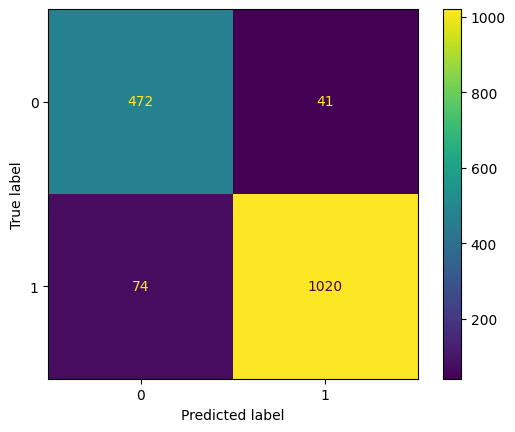

In [ ]:
# disegnamo la confusion matrix in modo da capire se il nostro modello funziona o no
y_pred = LR1.predict(scaled_X_test)
metrics.ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=LR1.classes_)

plt.show()

In [ ]:
# misuriamo la performance del nostro classificatore
accuracy    = metrics.accuracy_score    (y_test, y_pred) # pos_label indica la label positiva
precision   = metrics.precision_score   (y_test, y_pred)
recall      = metrics.recall_score      (y_test, y_pred)
f1_score    = metrics.f1_score          (y_test, y_pred)
MCC_score   = metrics.matthews_corrcoef (y_test, y_pred)

print(accuracy)
print(precision)
print(recall)
print(f1_score)
print(MCC_score)

0.9284380833851898
0.9613572101790764
0.9323583180987203
0.9466357308584686
0.8390256944370927


In [ ]:
# Ottimizzazione threshold
y_proba = LR1.predict_proba(scaled_X_test)[:, 1]
thresholds = np.linspace(0, 1, 1001)

best_mcc = -1
best_threshold = None

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    mcc = metrics.matthews_corrcoef(y_test, y_pred)

    if mcc > best_mcc:
        best_mcc = mcc
        best_threshold = t

print('Il threshold che migliore è ', best_threshold, ' poiché produce il valore massimo di MCC = ', best_mcc)

Il threshold che migliore è  0.389  poiché produce il valore massimo di MCC =  0.8426796168470467


## Approccio 2: mettere i NaN a 0

In [ ]:
df_2 = classification_df.copy()



df_2[speeds] = df_2[speeds].fillna(0)

# togliamo le eventuali righe in cui sono rimasti NaN
df_2 = df_2.dropna()

df_2.head()

,day,hour,elevation,PM10_1,NO2_1,AQI_1,power_area_50_1,temperature_1,winds_spd_1,precipitation_5,...,tuesday,wednesday,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Piana Rotaliana,Riva del Garda,Rovereto,Via Bolzano,target
8,1,9,410,19.0,15.0,23.750000,17.446178,10.95,0.0,0.0,...,False,False,True,False,False,False,False,False,False,1
9,1,10,410,22.0,15.0,25.000000,17.484408,11.55,0.0,0.0,...,False,False,True,False,False,False,False,False,False,1
10,1,11,410,26.0,18.0,30.000000,17.774180,12.15,0.0,0.0,...,False,False,True,False,False,False,False,False,False,1
11,1,12,410,23.0,17.0,27.500000,17.936620,12.85,0.0,0.0,...,False,False,True,False,False,False,False,False,False,1
12,1,13,410,30.0,18.0,36.666667,18.968706,13.80,0.0,0.0,...,False,False,True,False,False,False,False,False,False,1


In [ ]:
feature_cols = df_2.columns.difference(['target'])

# creiamo train, valid e test
X_train, X_test, y_train, y_test= train_test_split(df_2[feature_cols], df_2['target'], test_size=0.2, random_state=seed)

# riscalo mettendo la media a 0 e la deviazione std a 1
non_num_features = ['day', 'hour', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday', 'Borgo Valsugana', 'Monte Gaza', 'Parco S. Chiara', 
                    'Rovereto', 'Via Bolzano']
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_test = scaler.transform(X_test[num_features])

scaled_X_train = X_train.copy()
scaled_X_test = X_test.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_test[num_features] = scaled_num_X_test

scaled_X_train.head()

,AQI_1,AQI_2,AQI_3,Borgo Valsugana,Monte Gaza,NO2_1,NO2_2,NO2_3,PM10_1,PM10_2,...,sunday,temperature_1,temperature_2,temperature_3,thursday,tuesday,wednesday,winds_spd_1,winds_spd_2,winds_spd_3
7536,1.300973,0.619426,-0.137768,False,False,0.701829,0.309508,0.878410,0.216101,0.018096,...,False,-1.417894,-1.213753,-1.088407,True,False,False,-0.033114,0.088516,-0.032121
8919,-0.689695,-0.707754,-1.174123,False,False,0.141514,0.110924,-0.721028,-0.774762,-0.824769,...,False,-1.156899,-1.119423,-1.066206,False,False,True,1.717962,2.477130,2.190571
2682,-0.618600,-0.745673,-0.632176,False,True,-1.209835,-1.246067,-1.287496,-1.072021,-1.072670,...,False,0.520137,0.661737,0.621076,False,False,False,-0.680773,-0.683561,-0.684433
7788,1.983488,0.695265,0.318609,False,False,1.756540,1.931278,1.644807,0.513359,0.960121,...,False,-1.329045,-1.285887,-1.210513,False,False,False,-0.009127,-0.080376,-0.128760
3407,-0.632819,-0.404398,-0.061705,False,False,-0.089204,-0.021466,0.078691,-0.477503,-0.328966,...,True,-1.068049,-1.036191,-1.088407,False,False,False,1.598025,0.981230,1.175864


In [ ]:
# inizializziamo il classificatore
LR2 = LogisticRegressionCV(
    Cs=10,                              # numero di C = 1/lambda testati
    cv=5,                               # cv = n => n-fold cross validation
    penalty='elasticnet',
    solver='saga',                      # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],    # ratei tra l1 e l2 da testare
    scoring="accuracy",                 # scegliamo di basare la nostra ottimizzazione sull'accuratezza del modello
    max_iter=5000,                      # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                        # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',            # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed)

In [ ]:
# alleniamo il modello sul nostro insieme di training
LR2.fit(scaled_X_train,y_train)

LogisticRegressionCV(class_weight='balanced', cv=5,
                     l1_ratios=[0, 0.25, 0.5, 0.75, 1.0], max_iter=5000,
                     n_jobs=-1, penalty='elasticnet', random_state=12,
                     scoring='accuracy', solver='saga')

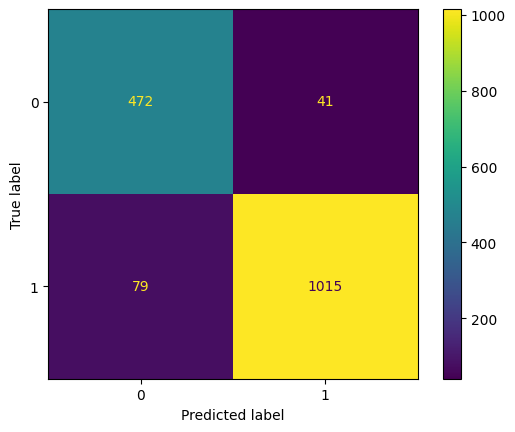

In [ ]:
# disegnamo la confusion matrix in modo da capire se il nostro modello funziona o no
y_pred = LR2.predict(scaled_X_test)
metrics.ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=LR2.classes_)

plt.show()

In [ ]:
# misuriamo la performance del nostro classificatore
accuracy    = metrics.accuracy_score    (y_test, y_pred) # pos_label indica la label positiva
precision   = metrics.precision_score   (y_test, y_pred)
recall      = metrics.recall_score      (y_test, y_pred)
f1_score    = metrics.f1_score          (y_test, y_pred)
MCC_score   = metrics.matthews_corrcoef (y_test, y_pred)

print(accuracy)
print(precision)
print(recall)
print(f1_score)
print(MCC_score)

0.925326695706285
0.9611742424242424
0.9277879341864717
0.9441860465116279
0.8326965349367595


In [ ]:
# Ottimizzazione threshold
y_proba = LR2.predict_proba(scaled_X_test)[:, 1]
thresholds = np.linspace(0, 1, 1001)

best_mcc = -1
best_threshold = None

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    mcc = metrics.matthews_corrcoef(y_test, y_pred)

    if mcc > best_mcc:
        best_mcc = mcc
        best_threshold = t

print('Il threshold che migliore è ', best_threshold, ' poiché produce il valore massimo di MCC = ', best_mcc)

Il threshold che migliore è  0.352  poiché produce il valore massimo di MCC =  0.8449263518651691


## Approccio 3: mettere i NaN uguali alla media

In [ ]:
df_3 = classification_df.copy()

# togliamo le eventuali righe in cui sono rimasti NaN
# per il momento lasciamo i NaN nelle colonne delle precipitazioni perché li sostituiremo dopo e altrimenti butteremmo via più righe del necessario
cols_to_check = df_3.columns.difference(speeds)
df_3 = df_3.dropna(subset=cols_to_check)

df_3.head()

,day,hour,elevation,PM10_1,NO2_1,AQI_1,power_area_50_1,temperature_1,winds_spd_1,precipitation_5,...,tuesday,wednesday,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Piana Rotaliana,Riva del Garda,Rovereto,Via Bolzano,target
8,1,9,410,19.0,15.0,23.750000,17.446178,10.95,NaN,0.0,...,False,False,True,False,False,False,False,False,False,1
9,1,10,410,22.0,15.0,25.000000,17.484408,11.55,NaN,0.0,...,False,False,True,False,False,False,False,False,False,1
10,1,11,410,26.0,18.0,30.000000,17.774180,12.15,NaN,0.0,...,False,False,True,False,False,False,False,False,False,1
11,1,12,410,23.0,17.0,27.500000,17.936620,12.85,NaN,0.0,...,False,False,True,False,False,False,False,False,False,1
12,1,13,410,30.0,18.0,36.666667,18.968706,13.80,NaN,0.0,...,False,False,True,False,False,False,False,False,False,1


In [ ]:
feature_cols = df_3.columns.difference(['target'])

# creiamo train, valid e test
X_train, X_test, y_train, y_test= train_test_split(df_3[feature_cols], df_3['target'], test_size=0.2, random_state=seed)

# riscalo mettendo la media a 0 e la deviazione std a 1
non_num_features = ['day', 'hour', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday', 'Borgo Valsugana', 'Monte Gaza', 'Parco S. Chiara', 
                    'Rovereto', 'Via Bolzano']
num_features = X_train.columns.difference(non_num_features)

# in questo caso scegliamo di calcolare la media (che poi useremo per sostituire i NaN) solo dopo aver separato i dati, in questo modo evitiamo
# data leakage
train_mean = X_train[speeds].mean()
for i in [X_train, X_test]:
    i[speeds] = i[speeds].fillna(train_mean)


scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_test = scaler.transform(X_test[num_features])

scaled_X_train = X_train.copy()
scaled_X_test = X_test.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_test[num_features] = scaled_num_X_test

scaled_X_train.head()

,AQI_1,AQI_2,AQI_3,Borgo Valsugana,Monte Gaza,NO2_1,NO2_2,NO2_3,PM10_1,PM10_2,...,sunday,temperature_1,temperature_2,temperature_3,thursday,tuesday,wednesday,winds_spd_1,winds_spd_2,winds_spd_3
7536,1.300973,0.619426,-0.137768,False,False,0.701829,0.309508,0.878410,0.216101,0.018096,...,False,-1.417894,-1.213753,-1.088407,True,False,False,-9.478163e-01,-7.903596e-01,-0.955624
8919,-0.689695,-0.707754,-1.174123,False,False,0.141514,0.110924,-0.721028,-0.774762,-0.824769,...,False,-1.156899,-1.119423,-1.066206,False,False,True,1.422333e+00,2.454674e+00,2.066463
2682,-0.618600,-0.745673,-0.632176,False,True,-1.209835,-1.246067,-1.287496,-1.072021,-1.072670,...,False,0.520137,0.661737,0.621076,False,False,False,2.883720e-16,2.911282e-16,0.000000
7788,1.983488,0.695265,0.318609,False,False,1.756540,1.931278,1.644807,0.513359,0.960121,...,False,-1.329045,-1.285887,-1.210513,False,False,False,-9.153485e-01,-1.019806e+00,-1.087020
3407,-0.632819,-0.404398,-0.061705,False,False,-0.089204,-0.021466,0.078691,-0.477503,-0.328966,...,True,-1.068049,-1.036191,-1.088407,False,False,False,1.259994e+00,4.224309e-01,0.686814


In [ ]:
# inizializziamo il classificatore
LR3 = LogisticRegressionCV(
    Cs=10,                              # numero di C = 1/lambda testati
    cv=5,                               # cv = n => n-fold cross validation
    penalty='elasticnet',
    solver='saga',                      # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],    # ratei tra l1 e l2 da testare
    scoring="accuracy",                 # scegliamo di basare la nostra ottimizzazione sull'accuratezza del modello
    max_iter=5000,                      # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                        # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',            # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed)

In [ ]:
# alleniamo il modello sul nostro insieme di training
LR3.fit(scaled_X_train,y_train)

LogisticRegressionCV(class_weight='balanced', cv=5,
                     l1_ratios=[0, 0.25, 0.5, 0.75, 1.0], max_iter=5000,
                     n_jobs=-1, penalty='elasticnet', random_state=12,
                     scoring='accuracy', solver='saga')

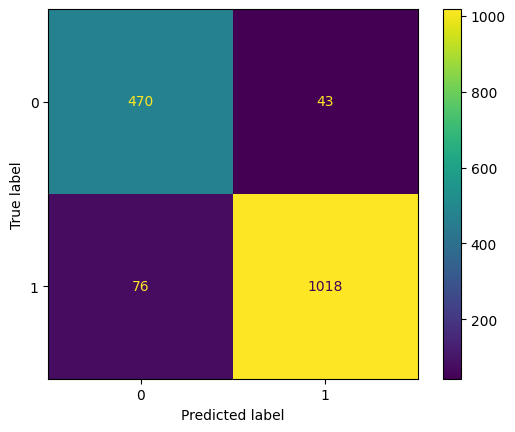

In [ ]:
# disegnamo la confusion matrix in modo da capire se il nostro modello funziona o no
y_pred = LR3.predict(scaled_X_test)
metrics.ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=LR3.classes_)

plt.show()

In [ ]:
# misuriamo la performance del nostro classificatore
accuracy    = metrics.accuracy_score    (y_test, y_pred) # pos_label indica la label positiva
precision   = metrics.precision_score   (y_test, y_pred)
recall      = metrics.recall_score      (y_test, y_pred)
f1_score    = metrics.f1_score          (y_test, y_pred)
MCC_score   = metrics.matthews_corrcoef (y_test, y_pred)

print(accuracy)
print(precision)
print(recall)
print(f1_score)
print(MCC_score)

0.9259489732420659
0.9594721960414703
0.9305301645338209
0.9447795823665893
0.8333889997009882


In [ ]:
# Ottimizzazione threshold
y_proba = LR3.predict_proba(scaled_X_test)[:, 1]
thresholds = np.linspace(0, 1, 1001)

best_mcc = -1
best_threshold = None

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    mcc = metrics.matthews_corrcoef(y_test, y_pred)

    if mcc > best_mcc:
        best_mcc = mcc
        best_threshold = t

print('Il threshold che migliore è ', best_threshold, ' poiché produce il valore massimo di MCC = ', best_mcc)

Il threshold che migliore è  0.362  poiché produce il valore massimo di MCC =  0.8437100964714755


## Conclusioni

Anche se di poco, rinunciare ai dati delle velocità dei venti è l'approccio che produce l'MCC migliore e tappare i buchi sembra fare più male che bene. Per questo motivo in tutti i notebook addestriamo i modelli facendo a meno dei dati sul vento.

In [ ]:
print(df_1.shape)
print(df_2.shape)
print(df_3.shape)

(8032, 36)
(8032, 39)
(8032, 39)
